(composite_datasets)=

# Joint reanalysis of CyteBase datasets

Combine cells from several CyteBase datasets, run a joint RNA analysis, and reopen
its results later. Counts stay in the source datasets; your new results are saved
locally.

This example combines human blood and PBMC data from [Wilk et al. (2020)](https://doi.org/10.1038/s41591-020-0944-y),
[Lee et al. (2020)](https://doi.org/10.1126/sciimmunol.abd1554), Arunachalam et al.,
and Schulte-Schrepping et al. The latter two are study-specific subsets republished
by [Jin et al. (2021)](https://doi.org/10.1016/j.isci.2021.103115).

The four sources contain 244,389 cells. We include all 233,870 primary COVID-19 or
normal cells before QC, with no random subsampling, and compare matched analyses
before and after Harmony correction by study. This is a joint reanalysis example,
not a test of disease effects.

Use a Python 3.12+ notebook environment with this checkout installed:

```bash
uv pip install -e ".[cytebase,extra]"
```

The public catalog requires network access but no token.

## 1. Choose datasets

The IDs below select the four studies. For your own analysis, choose compatible
datasets from the same organism with matching gene IDs.

In [1]:
# Import the catalog, composite creator, and notebook display tools.
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

import cytearc
from cytearc.composite import create_composite
from cytearc.cytebase import Catalog

# Choose resources for source reads, composite creation, and the pipeline.
memory_budget = "6G"
workers = 4

# Keep routine pipeline progress out of the notebook output.
cytearc.configure_output(level="WARNING", progress=False)

# Open the public catalog anonymously; counts remain remote.
catalog = Catalog(bucket="Nygen/cytebase", token=False)

Started: 2026-10-09T19:18:57.113913Z | Wall time: 5.152 s

The names on the left become values in the composite's `dataset` column.
Replace the IDs or add entries to use other studies.

In [2]:
# Pin the four CyteBase datasets under names used in the joint analysis.
dataset_ids = {
    "blood_wilk": "wilk_2020_single_cell_atlas_peripheral_sars_cov_2_infection_456e8b9b",
    "blood_lee": "lee_2020_immunophenotyping_covid_19_development_severe_covid_19_de2c780c",
    "blood_arunachalam": "jin_2021_individual_single_cell_rna_seq_pbmc_data_arunachalam_et_al_59b69042",
    "blood_schulte_schrepping": "jin_2021_individual_single_cell_rna_seq_data_schulte_schrepping_et_al_5e717147",
}

Started: 2026-10-09T19:19:02.270659Z | Wall time: 0.006 s

Open the prepared source datasets through the catalog. These datastores are
read-only; analysis results will be written to the new composite.

In [3]:
# Open each source once and retain it for composite creation.
sources = {
    name: catalog.open_datastore(
        dataset_id,
        mem_budget=memory_budget,
        nthreads=workers,
    )
    for name, dataset_id in dataset_ids.items()
}

Started: 2026-10-09T19:19:02.279523Z | Wall time: 14.468 s

## 2. Select cells

Include every primary cell whose disease label is `COVID-19` or `normal`. This
excludes Lee's influenza samples and does not impose a per-study cell cap.

`rows` contains positions in each original source dataset. Omitting `rows` from
`create_composite` includes all stored cells, including inactive ones.

In [4]:
# Select primary COVID-19 and normal cells using the original source metadata.
rows = {}
for name, source in sources.items():
    primary = source.cells.fetch_all("is_primary_data")
    disease = source.cells.fetch_all("disease")
    selected = np.flatnonzero(primary & np.isin(disease, ["COVID-19", "normal"]))

    # Require every chosen study to contribute cells.
    if selected.size == 0:
        raise ValueError(f"No primary COVID-19 or normal cells selected for {name!r}")
    rows[name] = selected

# Show the complete selected size for each study before QC.
display(
    pd.DataFrame(
        {
            "source_cells": {name: source.cells.N for name, source in sources.items()},
            "selected_cells": {name: len(selected) for name, selected in rows.items()},
        }
    )
)

,source_cells,selected_cells
blood_wilk,44721,44721
blood_lee,59572,49053
blood_arunachalam,49139,49139
blood_schulte_schrepping,90957,90957


Started: 2026-10-09T19:19:16.752266Z | Wall time: 1.027 s

## 3. Create the composite

Use `features="intersection"` to keep the 19,405 gene IDs shared by all four
sources. `features="union"` would retain every gene, filling absent source genes
with zeros; absence from a source is not evidence that a gene was unexpressed.

Choose a new local path. Creation scans the selected counts to prepare the
composite, but leaves the counts in their source datasets. If the path already
exists, reopen it using the example at the end of this notebook.

In [5]:
# Choose a new local destination outside every source store.
joint_path = Path("joint_cytebase.zarr")

# Create an ordinary writable DataStore with counts backed by the selected sources.
joint = create_composite(
    sources,
    at=joint_path,
    assay="RNA",
    features="intersection",
    rows=rows,
    mem_budget=memory_budget,
    nthreads=workers,
)

# Confirm the combined cells and shared genes.
print(f"{joint.cells.N:,} cells and {joint.RNA.feats.N:,} shared genes")

233,870 cells and 19,405 shared genes


Started: 2026-10-09T19:19:17.782785Z | Wall time: 354.054 s

The `dataset` column identifies each cell's source. Original metadata is preserved
with an `orig_` prefix. Check the cells and donors in each study and condition
before correcting by study. Donor IDs are interpreted within their source study;
matching strings across studies do not establish a shared donor.

In [6]:
# Freeze the same design columns, with the Harmony column first, in both runs.
snapshot_columns = ["dataset", "orig_disease", "orig_donor_id"]
design = joint.cells.to_pandas_dataframe(snapshot_columns, key=None)

# Check condition coverage and donor representation within each study.
display(
    design.groupby(["dataset", "orig_disease"], observed=True).agg(
        cells=("orig_donor_id", "size"),
        donors=("orig_donor_id", "nunique"),
    )
)

# Check whether any within-study donor appears in both conditions.
donor_conditions = design.groupby(["dataset", "orig_donor_id"], observed=True)[
    "orig_disease"
].nunique()
print(
    f"Within-study donors represented in both conditions: {(donor_conditions > 1).sum()}"
)

cells  donors
dataset                  orig_disease               
blood_arunachalam        COVID-19      23185       7
                         normal        25954       5
blood_lee                COVID-19      31463       8
                         normal        17590       4
blood_schulte_schrepping COVID-19      45170      18
                         normal        45787      21
blood_wilk               COVID-19      28094       7
                         normal        16627       6

Within-study donors represented in both conditions: 0


Started: 2026-10-09T19:25:11.840772Z | Wall time: 0.430 s

## 4. Run the uncorrected RNA pipeline

Run the usual pipeline to calculate PCA, UMAP, clusters, and markers. This example
applies MAD QC filtering separately within each dataset and uses a human gene
blacklist for feature selection. The same settings and frozen design columns are
used for the Harmony run. Author cell-type labels are not used to choose settings.

The retention table shows how QC affects each study and condition. Inspect removals
before reusing this filtering policy for another analysis. The UMAPs show the
retained cells colored by dataset and cluster.

In [7]:
# Define a human gene-symbol blacklist, including current histone names.
hvg_blacklist = "|".join(
    [
        r"^MT-",
        r"^RP[SL]\d+[AXY]?\d*$|^RPLP[0-2]$|^RPSA$|^MRP[SL]\d+[A-C]?$",
        r"^HLA-",
        r"^HIST[1-4]H|^H1-[1-6]$|^H1F[1-6]$|^H2AC\d+$|^H2BC\d+$"
        r"|^H3C\d+$|^H4C\d+$|^H2AW$|^H3-4$|^H4-16$",
        r"^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$|^SRY$|^ZFY$"
        r"|^UTY$|^TMSB4Y$|^NLGN4Y$",
    ]
)

# Keep the reviewed filtering and feature settings shared between comparison runs.
filtering = {"method": "mad", "sample_column": "dataset", "n_mads": 5}
pipeline_params = {
    "species": "homo_sapiens",
    "hvg": {"blacklist": hvg_blacklist},
}

# Run joint analysis without batch correction as the comparison baseline.
baseline = joint.pipeline.run(
    assay="RNA",
    label="joint_baseline",
    filtering=filtering,
    snapshot_columns=snapshot_columns,
    params=pipeline_params,
)

Started: 2026-10-09T19:25:12.273517Z | Wall time: 3913.846 s

included  retained  retained_fraction
dataset                  orig_disease                                       
blood_arunachalam        COVID-19         23185     23184              1.000
                         normal           25954     25953              1.000
blood_lee                COVID-19         31463     30592              0.972
                         normal           17590     17526              0.996
blood_schulte_schrepping COVID-19         45170     44003              0.974
                         normal           45787     45250              0.988
blood_wilk               COVID-19         28094     27687              0.986
                         normal           16627     16509              0.993

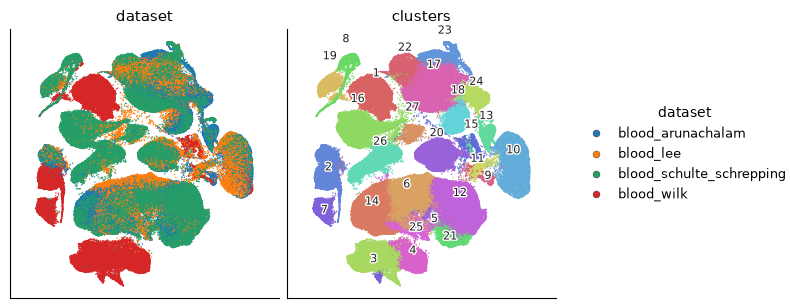

Started: 2026-10-09T20:30:26.124915Z | Wall time: 8.946 s

In [8]:
# Audit QC retention against all selected cells in each study and condition.
retention = design[["dataset", "orig_disease"]].copy()
retention["retained"] = baseline.cells.fetch_all("I")
display(
    retention.groupby(["dataset", "orig_disease"], observed=True)["retained"]
    .agg(included="size", retained="sum", retained_fraction="mean")
    .round(3)
)

# Show the uncorrected embedding by source study and by cluster.
joint.plots.embedding(run=baseline, color_by=["dataset", "clusters"], n_columns=2)

## 5. Compare with Harmony correction

Save a second run with `harmony_batch_columns=["dataset"]`. Both runs use the same
cells and PCA; Harmony changes the coordinates used to construct the graph,
embedding, and clusters. Source counts remain unchanged.

Compare the plots below with the uncorrected plots above. More mixing alone does
not establish a better biological result: studies differ in cohort, collection,
and technology, and their cell populations need not have the same composition.
This notebook does not infer disease effects from the corrected embedding.

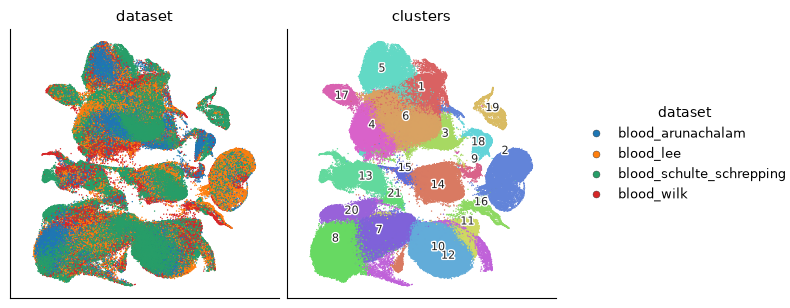

Started: 2026-10-09T20:30:35.075120Z | Wall time: 1554.795 s

In [9]:
# Save the corrected analysis as a separate run with matched upstream settings.
run = joint.pipeline.run(
    assay="RNA",
    label="joint_harmony",
    filtering=filtering,
    harmony_batch_columns=["dataset"],
    snapshot_columns=snapshot_columns,
    params=pipeline_params,
)

# Confirm that both comparisons start from the same frozen cells and PCA.
assert baseline["analysis_cell_selection"] == run["analysis_cell_selection"]
assert baseline["pca"] == run["pca"]

# Show the corrected embedding using the same coloring as the baseline.
joint.plots.embedding(run=run, color_by=["dataset", "clusters"], n_columns=2)

## 6. Inspect results and reopen later

Load the saved markers and inspect each study's contribution to the corrected
clusters. These marker lists are a starting point for annotation, not cell-type
assignments.

In [10]:
# Summarize the top five saved marker genes per corrected cluster.
markers = joint.markers.load(marker=run["markers"])
display(
    markers.groupby("group_id", sort=False)
    .head(5)
    .groupby("group_id", sort=False)["feature_name"]
    .agg(", ".join)
    .rename("top_markers")
)

# Read study membership and clustering from the run's frozen cell view.
assignments = run.cells.to_pandas_dataframe(["dataset", "clusters"])
display(pd.crosstab(assignments["dataset"], assignments["clusters"]))

# Keep the corrected run label for the reopen call below.
run_label = run.label

group_id
1         SIGLEC1, OTOF, TCN2, CD163, APOBEC3A
2              TMEM40, GP9, CMTM5, ESAM, CLDN5
3              ENHO, CD1E, PKIB, CLEC10A, CD1C
5             LYPD2, VMO1, CDKN1C, NEURL1, CKB
6     CYP27A1, CXCL2, HOMER3, CYP1B1, TMEM176A
7        A2M-AS1, CD8A, LINC01871, TRGC2, CD8B
8            NCR1, NCAM1, SH2D1B, MYOM2, DTHD1
9             CD34, NPR3, CRHBP, CYTL1, PRSS57
10         MAL, NELL2, RETREG1, TRABD2A, TSHZ2
11        TSHZ2, ANK3, RNF157, CD28, CHRM3-AS2
12            SPC25, CDC45, MELK, MND1, PKMYT1
13       TNFRSF17, IGHG2, POU2AF1, ELL2, IGHA2
14       LINC02397, PAX5, FCRL1, PLEKHG1, EBF1
15       VPREB3, LINC00926, MS4A1, FCRLA, IGHD
16               ALAS2, AHSP, SLC4A1, CA1, HBM
17             ALPL, CMTM2, CXCR1, MME, KCNJ15
18           CLEC4C, LRRC26, LILRA4, SHD, PROC
19             CEACAM8, MMP8, LTF, BPI, ABCA13
20                   KLRF1, TRDC, KLRD1, KLRB1
Name: top_markers, dtype: str

clusters,1,2,3,4,5,6,7,8,9,10,...,12,13,14,15,16,17,18,19,20,21
dataset,,,,,,,,,,,,,,,,,,,,,
blood_arunachalam,2783,4342,2511,907,3302,4657,5248,6715,549,9200,...,366,1439,3198,19,308,84,2142,68,272,97
blood_lee,3135,3941,574,1705,2350,7481,6530,7736,34,6169,...,478,498,6023,53,423,227,110,68,327,69
blood_schulte_schrepping,3579,886,475,12225,3509,11012,7892,6123,70,16951,...,1107,5210,4583,1954,284,1881,482,1265,5735,2063
blood_wilk,3801,666,504,1928,1455,4789,5609,7108,301,7251,...,660,3185,3582,67,871,285,237,198,590,197


Started: 2026-10-09T20:56:29.874314Z | Wall time: 1.186 s

Reopen the local composite and load a saved pipeline run by its label. The
original CyteBase sources must remain available and unchanged because the
composite still reads their counts. Both analyses are saved in the local composite.

In [11]:
# Supply anonymous access for these public CyteBase sources on each reopen.
source_storage_options = {name: {"token": False} for name in dataset_ids}

# Reopen the composite through the ordinary DataStore constructor.
reopened = cytearc.DataStore(
    str(joint_path),
    min_features_per_cell=-1,
    mem_budget=memory_budget,
    nthreads=workers,
    source_storage_options=source_storage_options,
)

# Load the saved corrected run and confirm that its clustering is preserved.
reopened_run = reopened.pipeline.open(label=run_label)
assert reopened_run["clusters"] == run["clusters"]
print(f"Reopened {reopened_run.label}: {reopened_run.status}")

Reopened joint_harmony: completed


Started: 2026-10-09T20:56:31.064067Z | Wall time: 9.959 s

Continue with [quality control](quality_control.ipynb),
[Harmony comparisons](batch_correction.ipynb), or
[CyteBase discovery](cytebase.ipynb).